In [1]:
%matplotlib widget
from datetime import datetime, timedelta
import glob
from eigsep_observing import io
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.dates as mdates

In [2]:
DATA_DIR = "/home/eigsep/eigsep/data"
files = sorted(glob.glob(f"{DATA_DIR}/corr_20260716*.h5"))
files = np.array(files)
print(len(files))
hdr = io.read_hdf5(files[0])[1]
print(hdr.keys())
_data, hdr, metadata = io.read_hdf5(files[0])
print(_data.keys())
print(_data['0'].shape)

414
dict_keys(['acc_bins', 'adc_gain', 'adc_mux_sel', 'adc_snapshot_period_s', 'avg_even_odd', 'corr_acc_len', 'corr_scalar', 'corr_word', 'dfreq', 'diagnostics_period_s', 'dtype', 'fft_shift', 'fpg_file', 'header_upload_unix', 'imu_calibration_upload_unix', 'integration_time', 'linear_range_file', 'nchan', 'obs_config_owner', 'obs_config_owner_uploaded_unix', 'run_started_at_unix', 'run_tag', 'sample_rate', 'snap_ip', 'sync_time', 'upload_time', 'use_noise', 'use_ref', 'acc_cnt', 'fpg_version', 'freqs', 'imu_calibration', 'input_to_ant', 'obs_config', 'pairs', 'pol_delay', 'redis', 'times', 'wiring'])
dict_keys(['0', '02', '04', '1', '13', '15', '2', '24', '3', '35', '4', '5'])
(240, 1024)


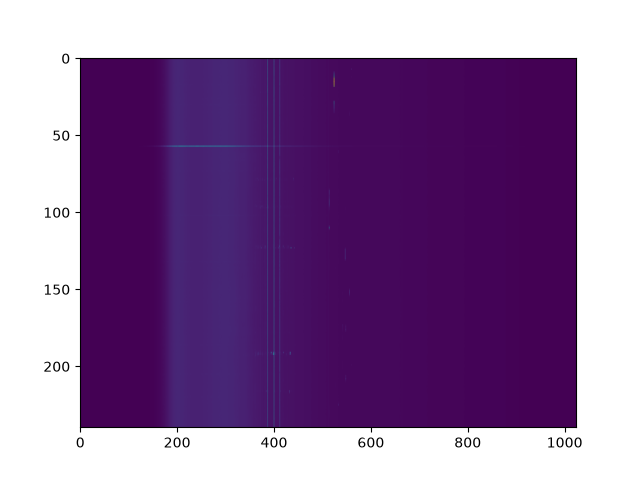

In [3]:
plt.figure()
plt.imshow(_data["0"], aspect="auto")
plt.show()

In [7]:
def get_dat(fname, key, missed=0):
    try:
        d = io.read_hdf5(fname)[0][key]
    except Exception:
        dtype = "float" if len(key) == 1 else "complex"
        d = np.zeros((240, 1024)).astype(dtype)
        missed += 1
    print(missed)
    return d

In [8]:
times = np.arange(len(_data["0"]))
freqs = hdr["freqs"]

d0 = np.array([get_dat(files[i], "0") for i in range(len(files))]).reshape(-1, len(freqs))

0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0


In [9]:
freqs

array([0.00000000e+00, 2.44140625e-01, 4.88281250e-01, ...,
       2.49267578e+02, 2.49511719e+02, 2.49755859e+02], shape=(1024,))

/tmp/ipykernel_20020/1517618277.py:5: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.log10(d0), **kwargs, vmin=4, vmax=6.6)
/tmp/ipykernel_20020/1517618277.py:5: RuntimeWarning: invalid value encountered in log10
  plt.imshow(np.log10(d0), **kwargs, vmin=4, vmax=6.6)


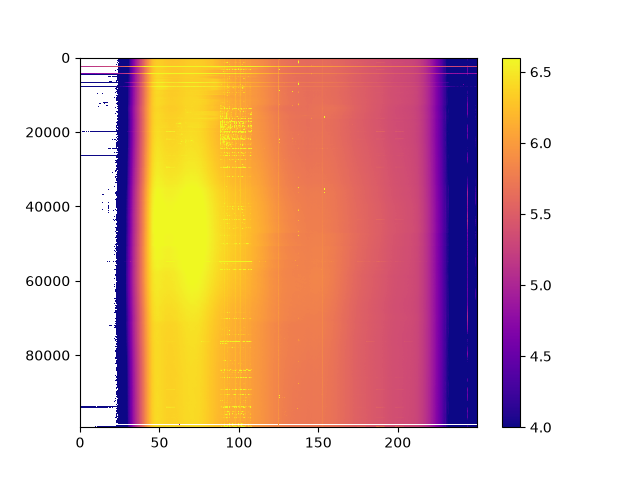

In [13]:
extent = [freqs.min(), freqs.max(), len(d0), 0]
kwargs = {"aspect": "auto", "cmap": "plasma", "extent": extent, "interpolation": "none"}

plt.figure()
plt.imshow(np.log10(d0), **kwargs, vmin=4, vmax=6.6)
plt.colorbar()
plt.show()